## Final data sci

#### Data loading

In [1]:
import importlib
from src import pipeline2


importlib.reload(pipeline2)

train_path="/data/train.csv"
test_path="/data/test.csv"

On va crée autant de pipeline que de types de features qu'on va considérer pour analyser chaque groupe entre eux.

In [2]:

pipe_action = pipeline2.Pipeline(
    test_path=test_path,
    train_path=train_path
)

pipe_temporal = pipeline2.Pipeline(
    test_path=test_path,
    train_path=train_path
)

pipe_screen = pipeline2.Pipeline(
    test_path=test_path,
    train_path=train_path
)

pipe_screen_config = pipeline2.Pipeline(
    test_path=test_path,
    train_path=train_path
)

pipe_chaine = pipeline2.Pipeline(
    test_path=test_path,
    train_path=train_path
)

pipes = [pipe_action, pipe_temporal, pipe_screen, pipe_screen_config, pipe_chaine]

for pipe in pipes:
    pipe.load_all_data()

✅ Data loaded successfully
✅ Data loaded successfully
✅ Data loaded successfully
✅ Data loaded successfully
✅ Data loaded successfully


## Features analysis

On va commencer par calculer les features propre à chaque pipe pour les analyser ensuite.

In [3]:
features_at_test = ["actions","temporal",
                    "screens", "screen_config",
                    "chaine"]


for i, features in enumerate(features_at_test):
    pipes[i].compute_features(include_groups=[features])

✅ Features computed: 36 columns in training set.


c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


✅ Features computed: 18 columns in training set.
✅ Features computed: 36 columns in training set.
✅ Features computed: 19 columns in training set.
✅ Features computed: 19 columns in training set.


### Action features

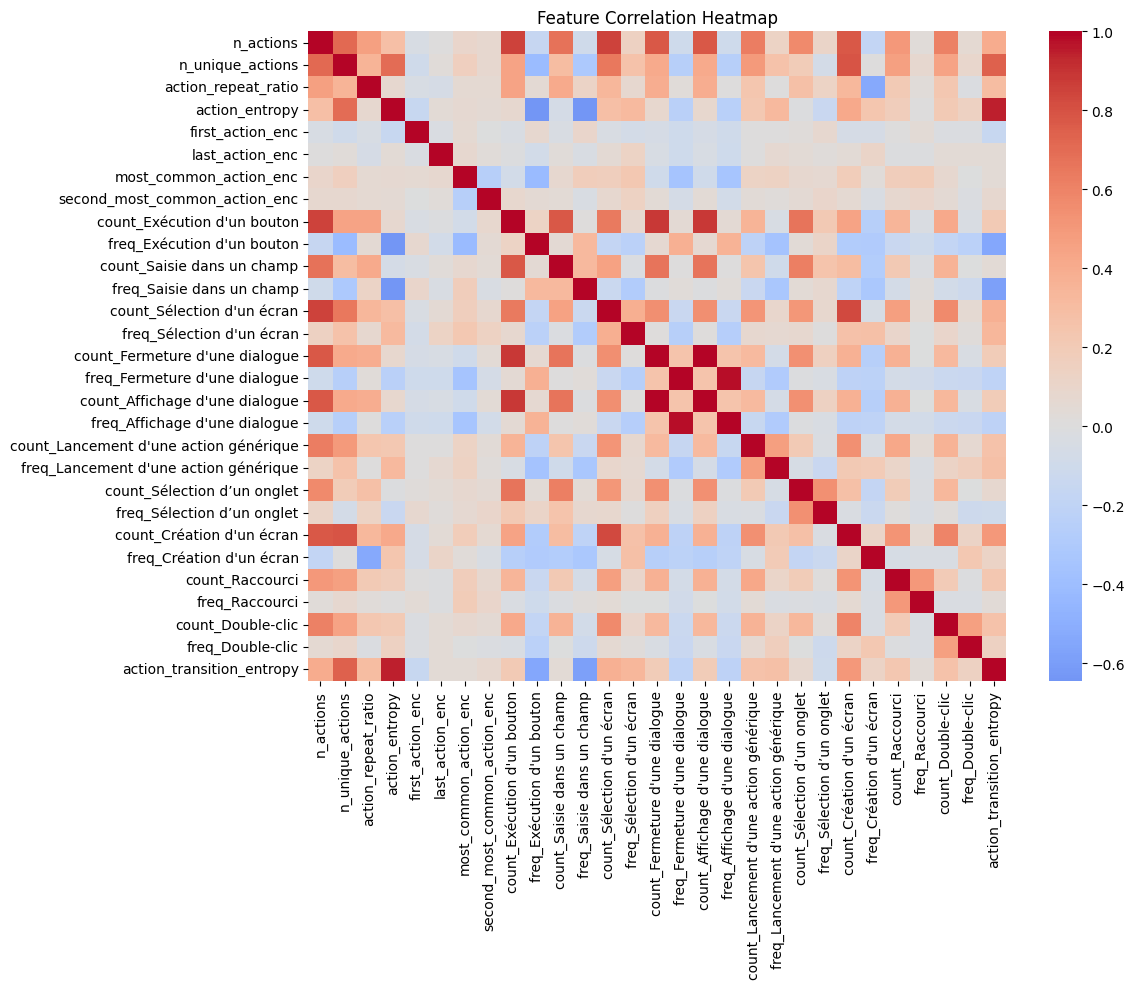

🔍 6 pairs of features with correlation > 0.85
correlated_pairs                           Feature 1                       Feature 2  \
11                        n_actions      count_Sélection d'un écran   
105                  action_entropy       action_transition_entropy   
201     count_Exécution d'un bouton  count_Fermeture d'une dialogue   
203     count_Exécution d'un bouton  count_Affichage d'une dialogue   
302  count_Fermeture d'une dialogue  count_Affichage d'une dialogue   
316   freq_Fermeture d'une dialogue   freq_Affichage d'une dialogue   

     Correlation  
11      0.850158  
105     0.947816  
201     0.880765  
203     0.879917  
302     0.999322  
316     0.979338  


,Feature 1,Feature 2,Correlation
11,n_actions,count_Sélection d'un écran,0.850158
105,action_entropy,action_transition_entropy,0.947816
201,count_Exécution d'un bouton,count_Fermeture d'une dialogue,0.880765
203,count_Exécution d'un bouton,count_Affichage d'une dialogue,0.879917
302,count_Fermeture d'une dialogue,count_Affichage d'une dialogue,0.999322
316,freq_Fermeture d'une dialogue,freq_Affichage d'une dialogue,0.979338


In [4]:
pipe_action.analyze_feature_correlation()


✅ Features computed: 31 columns in training set.


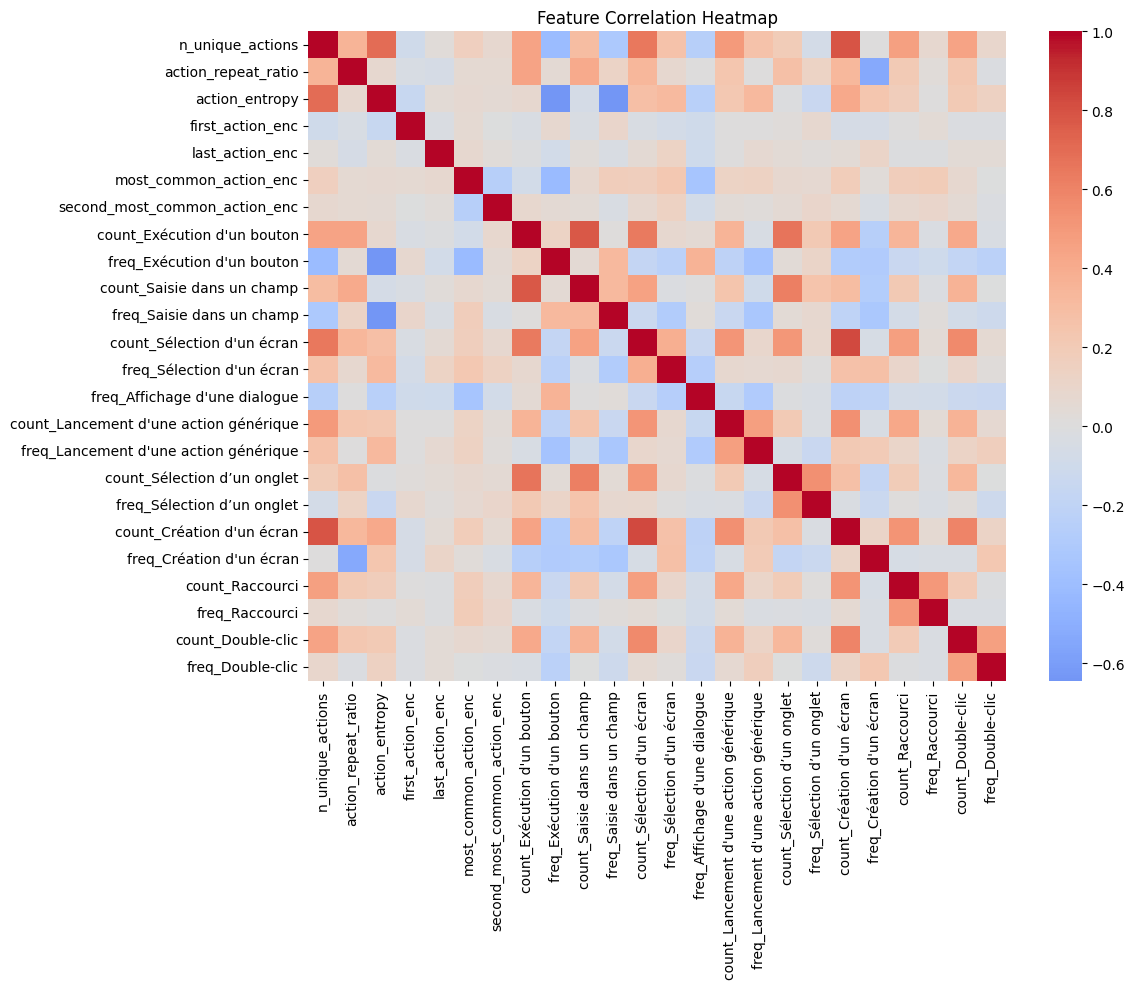

🔍 0 pairs of features with correlation > 0.85
correlated_pairs Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


,Feature 1,Feature 2,Correlation


In [5]:
exclude_set = ["n_actions",
        "action_transition_entropy",
        "count_Fermeture d'une dialogue",
        "freq_Fermeture d'une dialogue",
        "count_Affichage d'une dialogue"]

pipe_action.compute_features(
    include_groups=["actions"],
    exclude_features=exclude_set
    )

pipe_action.analyze_feature_correlation()

In [6]:
# pipe_action.prepare_data()
# cv_scores, perm_scores = pipe_action.analyze_feature_relevance()

In [7]:
action_exclude_set = exclude_set + [
    "count_Double-clic",
    "count_Création d'un écran",
    "count_Sélection d'un onglet",
    "count_Lancement d'une action générique",
    "count_Sélection d'un écran",
    "action_repeat_ratio"
]

### Screen features

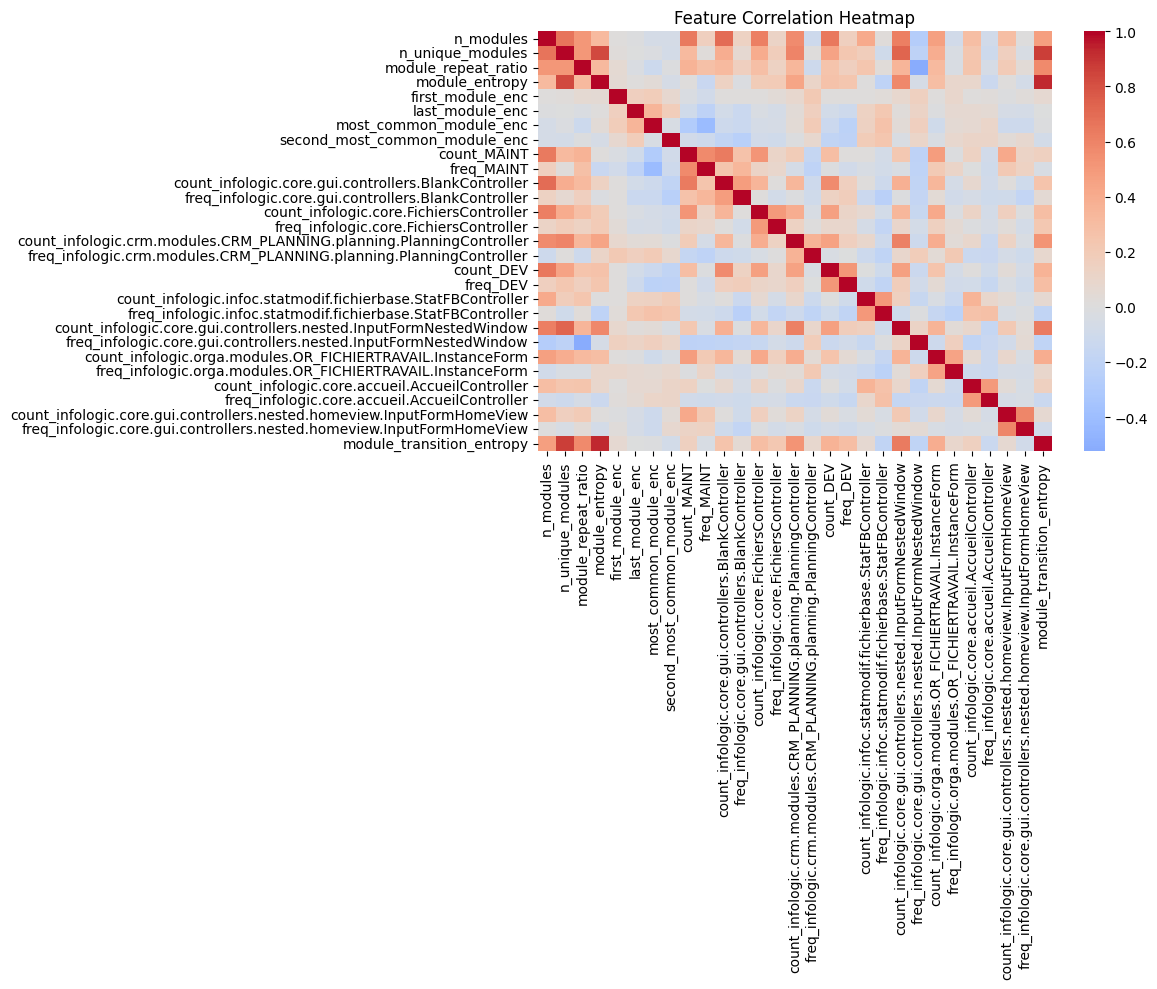

🔍 2 pairs of features with correlation > 0.85
correlated_pairs             Feature 1                  Feature 2  Correlation
54   n_unique_modules  module_transition_entropy     0.872062
105    module_entropy  module_transition_entropy     0.934488


,Feature 1,Feature 2,Correlation
54,n_unique_modules,module_transition_entropy,0.872062
105,module_entropy,module_transition_entropy,0.934488


In [8]:
pipe_screen.analyze_feature_correlation()

✅ Features computed: 35 columns in training set.


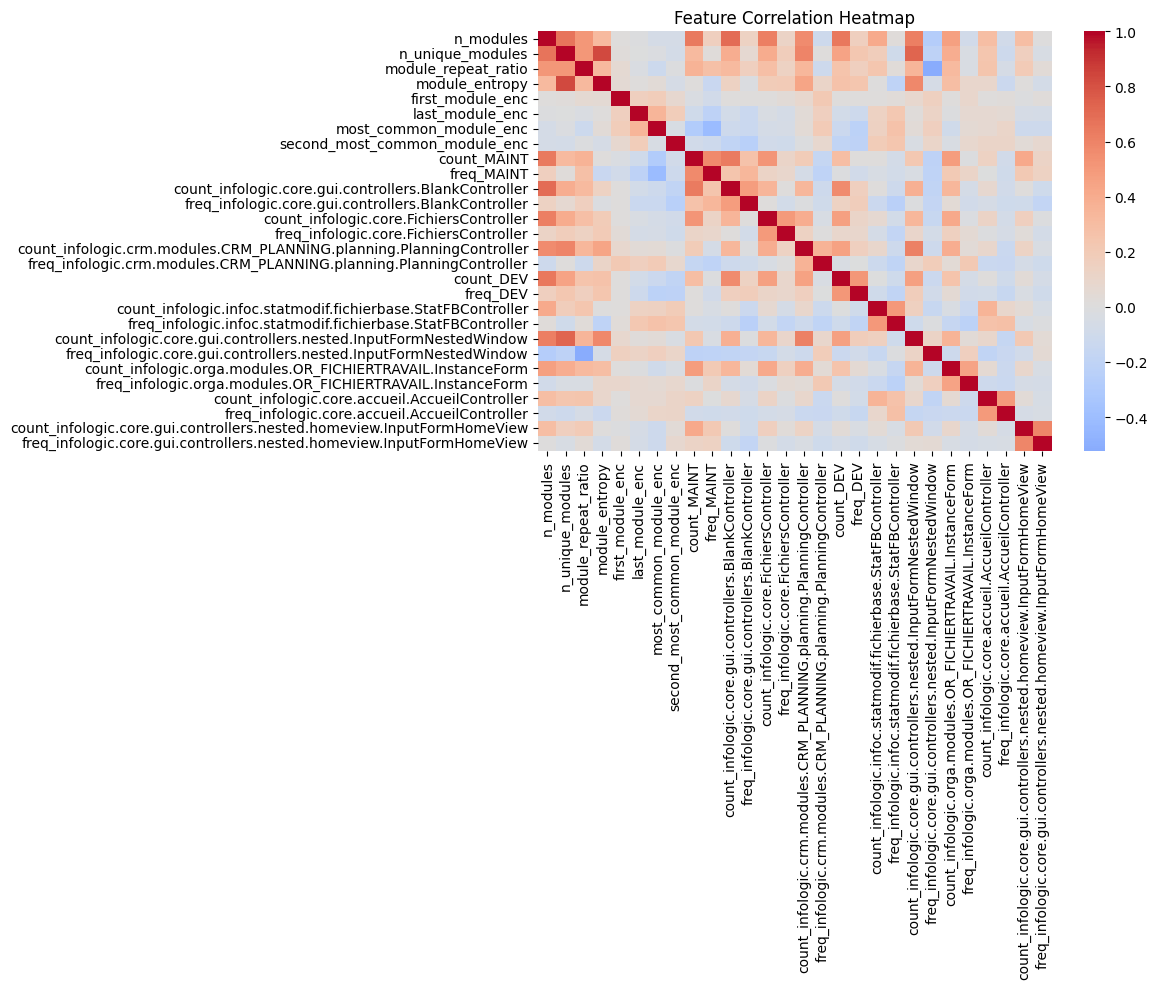

🔍 0 pairs of features with correlation > 0.85
correlated_pairs Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


,Feature 1,Feature 2,Correlation


In [9]:
exclude_set = ["module_transition_entropy"]
pipe_screen.compute_features(
    include_groups=["screens"],
    exclude_features=exclude_set
    )
pipe_screen.analyze_feature_correlation()

In [10]:
# pipe_screen.prepare_data()
# cv_scores, perm_scores = pipe_screen.analyze_feature_relevance()

In [11]:
screen_exclude_set = exclude_set

### Screen config features

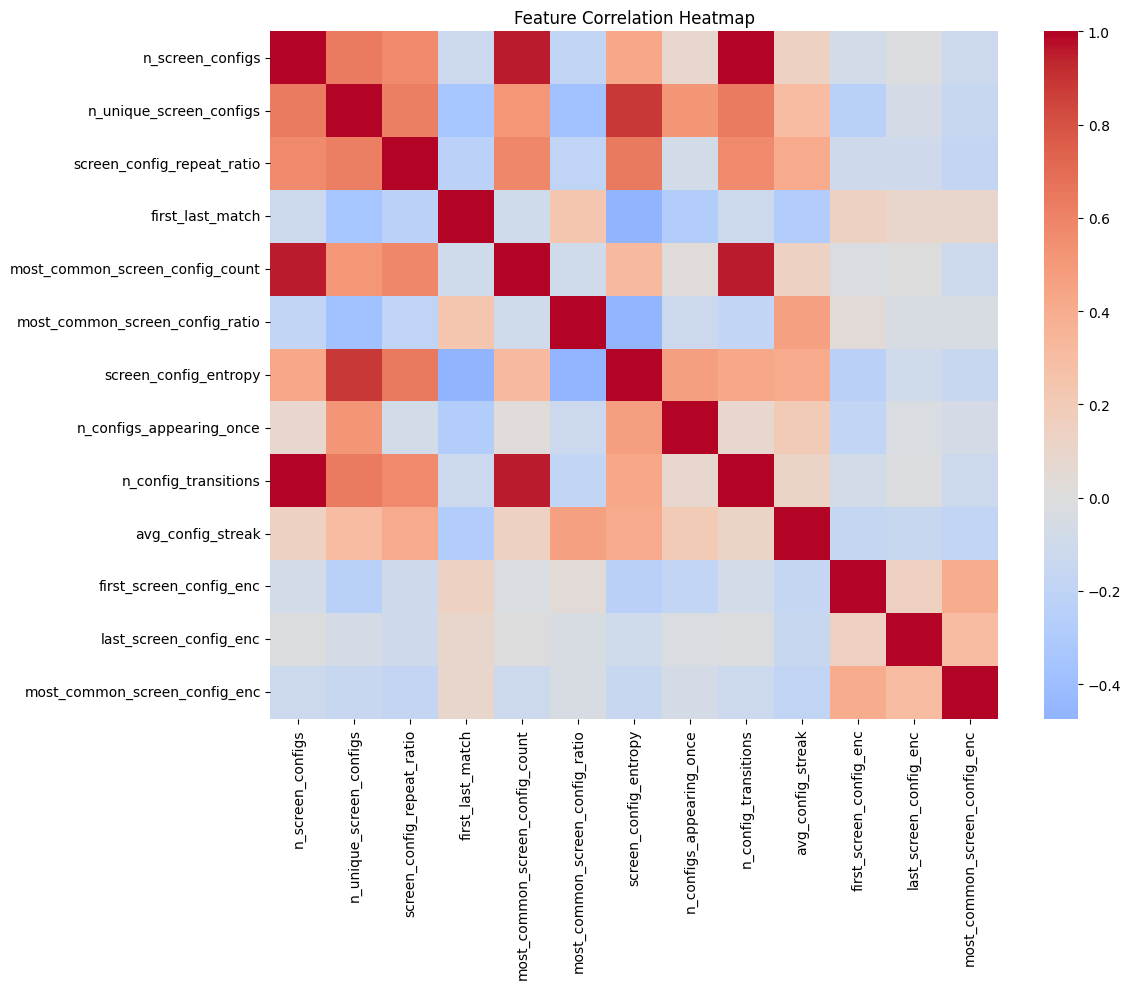

🔍 4 pairs of features with correlation > 0.85
correlated_pairs                           Feature 1                        Feature 2  \
3                  n_screen_configs  most_common_screen_config_count   
7                  n_screen_configs             n_config_transitions   
16          n_unique_screen_configs            screen_config_entropy   
45  most_common_screen_config_count             n_config_transitions   

    Correlation  
3      0.954567  
7      0.999301  
16     0.886605  
45     0.954341  


,Feature 1,Feature 2,Correlation
3,n_screen_configs,most_common_screen_config_count,0.954567
7,n_screen_configs,n_config_transitions,0.999301
16,n_unique_screen_configs,screen_config_entropy,0.886605
45,most_common_screen_config_count,n_config_transitions,0.954341


In [12]:
pipe_screen_config.analyze_feature_correlation()

✅ Features computed: 16 columns in training set.


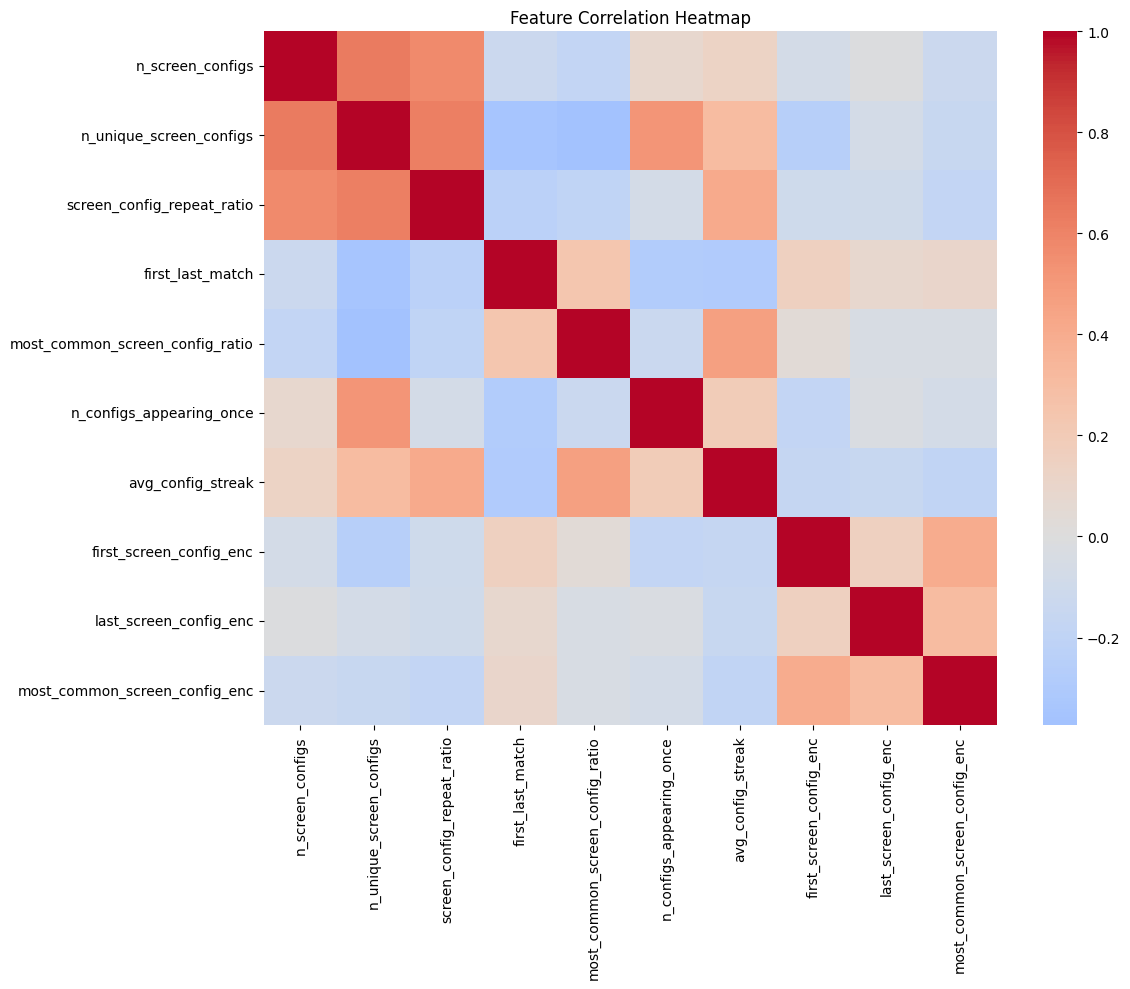

🔍 0 pairs of features with correlation > 0.85
correlated_pairs Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


,Feature 1,Feature 2,Correlation


In [13]:
exclude_set = [
    "n_config_transitions",
    "screen_config_entropy",
    "most_common_screen_config_count"
]
pipe_screen_config.compute_features(
    include_groups=["screen_config"],
    exclude_features=exclude_set
)
pipe_screen_config.analyze_feature_correlation()

In [14]:
# pipe_screen_config.prepare_data()
# cv_scores, perm_scores = pipe_screen_config.analyze_feature_relevance()

In [15]:
screen_config_exclude_set = exclude_set + [
    "first_last_match",
    "n_screen_config",
    "n_configs_appearing_once"
]

### Temporal features

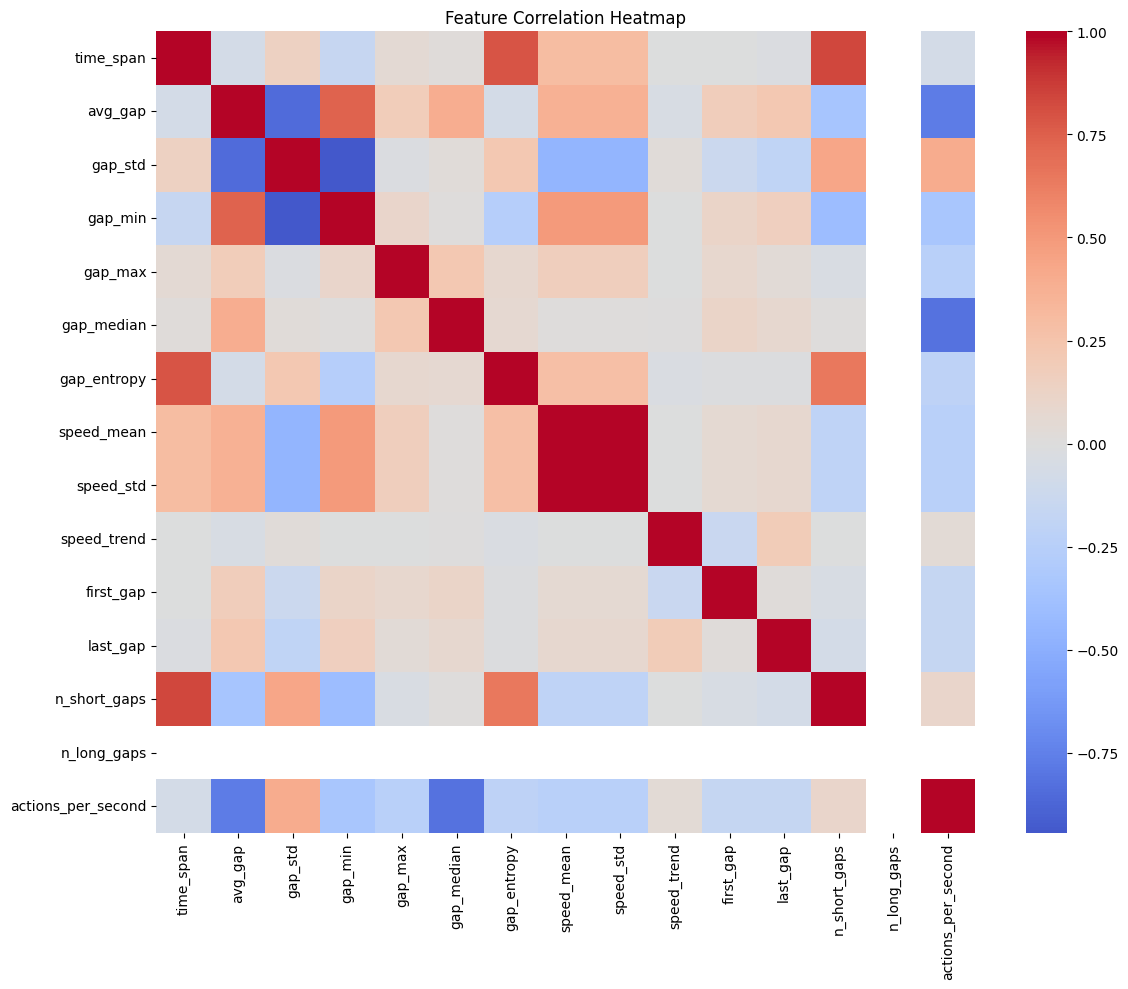

🔍 3 pairs of features with correlation > 0.85
correlated_pairs      Feature 1  Feature 2  Correlation
13     avg_gap    gap_std    -0.852454
25     gap_std    gap_min    -0.944157
70  speed_mean  speed_std     0.999989


,Feature 1,Feature 2,Correlation
13,avg_gap,gap_std,-0.852454
25,gap_std,gap_min,-0.944157
70,speed_mean,speed_std,0.999989


In [16]:
pipe_temporal.analyze_feature_correlation()

c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


✅ Features computed: 16 columns in training set.


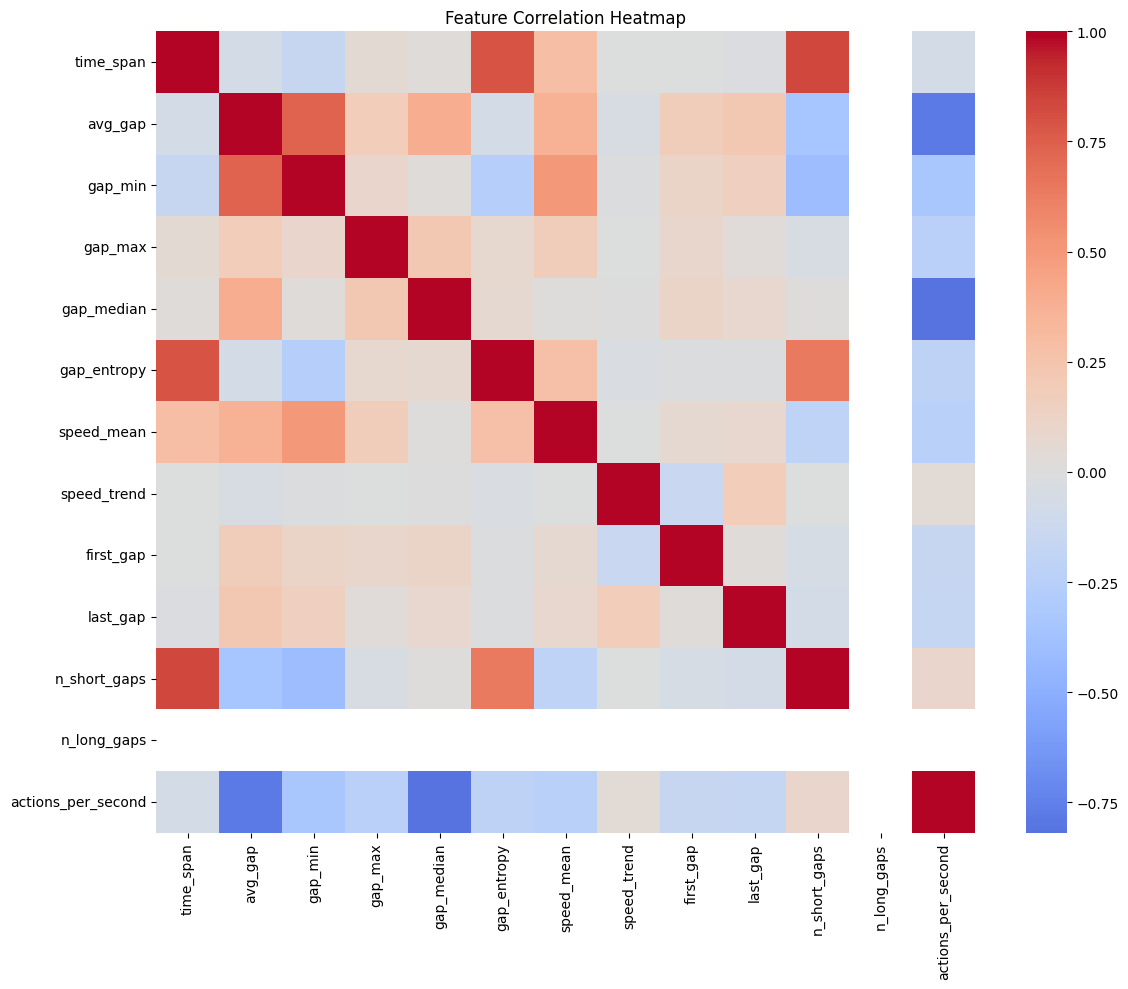

🔍 0 pairs of features with correlation > 0.85
correlated_pairs Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


,Feature 1,Feature 2,Correlation


In [17]:
exclude_set = [
    "gap_std",
    "speed_std"
]
pipe_temporal.compute_features(
    include_groups=["temporal"],
    exclude_features=exclude_set
)
pipe_temporal.analyze_feature_correlation()

In [18]:

# pipe_temporal.prepare_data()
# cv_scores, perm_scores = pipe_temporal.analyze_feature_relevance()

In [19]:
temporal_exclude_set = exclude_set + ["gap_median"]

### Chaine features

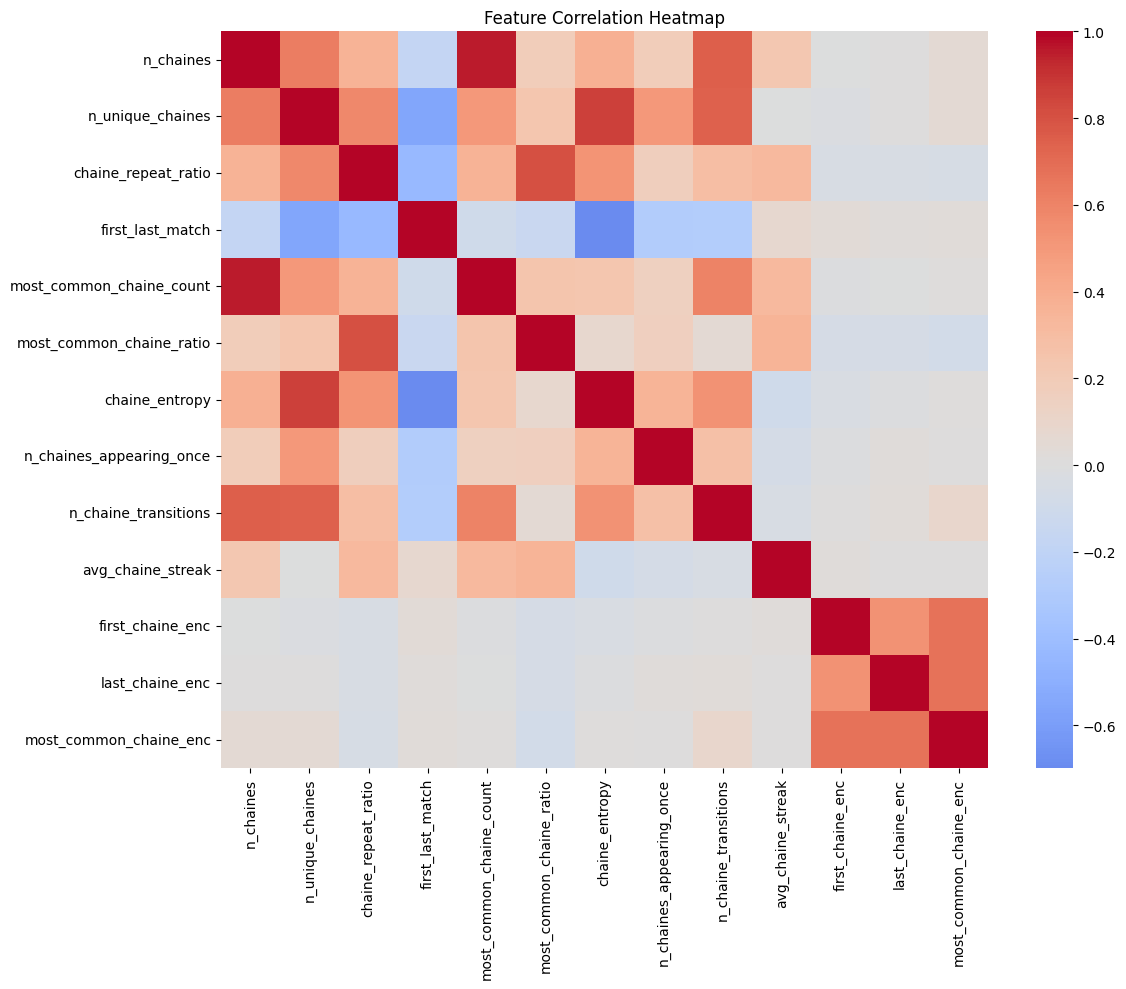

🔍 2 pairs of features with correlation > 0.85
correlated_pairs            Feature 1                 Feature 2  Correlation
3          n_chaines  most_common_chaine_count     0.957225
16  n_unique_chaines            chaine_entropy     0.860012


,Feature 1,Feature 2,Correlation
3,n_chaines,most_common_chaine_count,0.957225
16,n_unique_chaines,chaine_entropy,0.860012


In [20]:
pipe_chaine.analyze_feature_correlation()

✅ Features computed: 17 columns in training set.


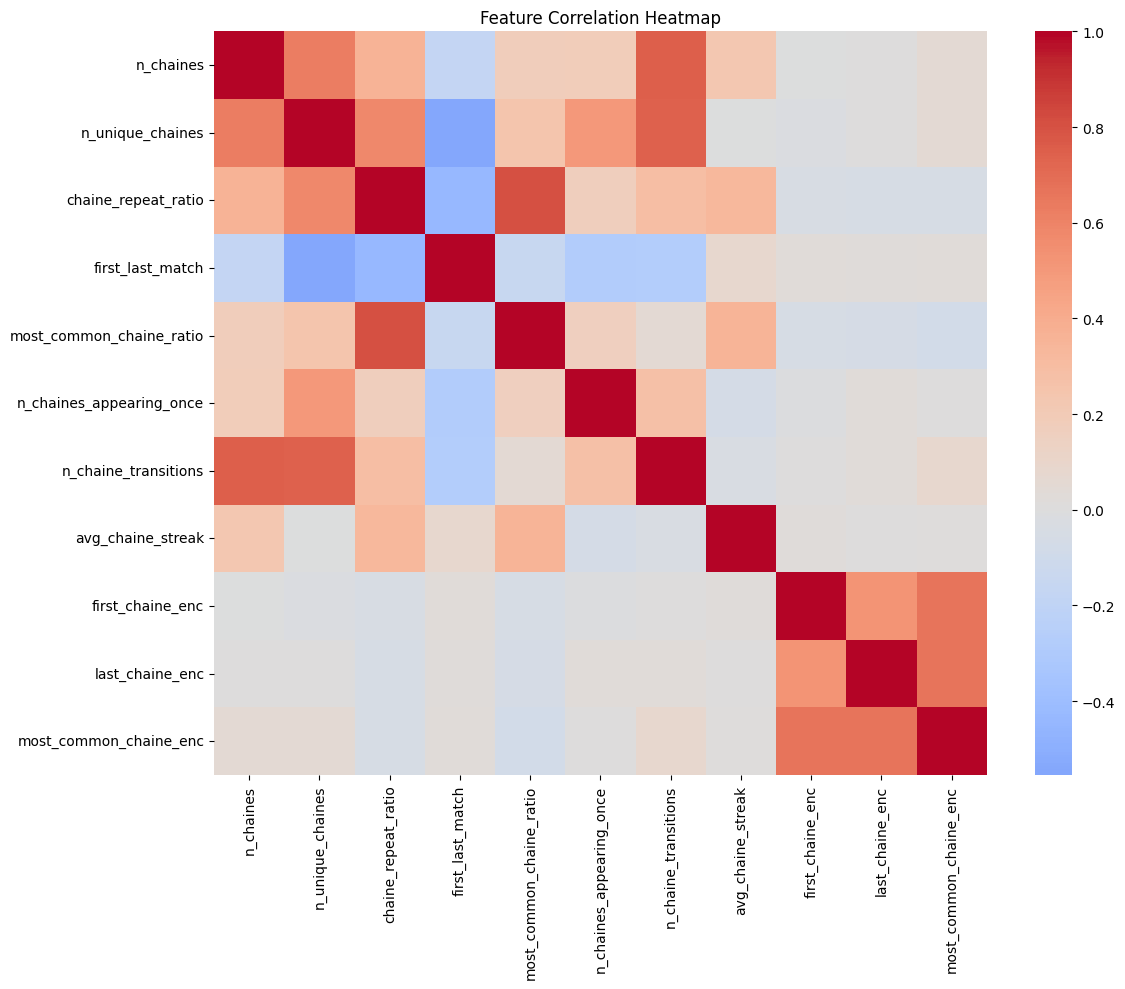

🔍 0 pairs of features with correlation > 0.85
correlated_pairs Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


,Feature 1,Feature 2,Correlation


In [21]:
exclude_set = [
    "most_common_chaine_count",
    "chaine_entropy"
]
pipe_chaine.compute_features(
    include_groups=["chaine"],
    exclude_features=exclude_set
)
pipe_chaine.analyze_feature_correlation()

In [22]:
# pipe_chaine.prepare_data()
# cv_scores, perm_scores = pipe_chaine.analyze_feature_relevance()

In [23]:
chaine_exclude_set = exclude_set + [
    "first_last_match",
    "n_unique_chaines",
    "n_chaine_appearing_once"
]

### Model

In [24]:
total_exclude_set = chaine_exclude_set + temporal_exclude_set + screen_config_exclude_set + screen_exclude_set + action_exclude_set

print(len(total_exclude_set))

pipeline = pipeline2.Pipeline(
    test_path="/data/test.csv",
    train_path="/data/train.csv"
    )
pipeline.load_all_data()
pipeline.compute_features(include_groups=['nav', 'actions','screens','temporal','screen_config','chaine'])
pipeline.prepare_data()

model, acc = pipeline.train_random_forest(exclude_features=total_exclude_set)

df = pipeline.predict_test_data(exclude_features=total_exclude_set)

df.head(-1)

pipeline.train_random_forest_full(exclude_features=total_exclude_set)

pipeline.generate_submission(output_path="data/submission.csv")



26
✅ Data loaded successfully


c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\src\features\base_features.py:155: RuntimeWarning: divide by zero encountered in divide
  speeds = np.arange(1, len(gaps)+1) / gaps if len(gaps)>0 else [0]
c:\Users\steph\OneDrive\Bureau\workspace\data_sci\.venv\lib\site-packages\numpy\_core\_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


✅ Features computed: 116 columns in training set.
✅ Data prepared (label encoding done).
✅ RandomForest trained. Accuracy on validation set: 0.7088
✅ RandomForest trained on full train set (3279 samples, 77 features).
✅ Submission saved to data/submission.csv
